# Tokopedia Sentiment Scraper & Analyzer

Notebook ini melakukan scraping ulasan toko Tokopedia, analisis sentimen & NLP sederhana,
menyimpan hasil ke Excel, lalu menampilkan ringkasan dan dashboard visualisasi.

Jalankan **sel per sel** dari atas ke bawah.

## 1. Import Library

In [1]:
from selenium import webdriver
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
import time
import re
import os

%matplotlib inline

## 2. Konfigurasi

Atur stopwords, keyword tema, dan lokasi penyimpanan file Excel.

In [2]:
STOPWORDS = {
    'dan', 'yang', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk',
    'sudah', 'saya', 'tp', 'nya', 'ya', 'tidak', 'bisa', 'ada', 'tapi',
    'juga', 'sangat', 'barang', 'produk', 'good', 'oke', 'ok', 'gak',
    'ga', 'aja', 'udah', 'bgt', 'banget', 'sih', 'deh', 'lah', 'nih',
    'kalau', 'kalo', 'karena', 'jadi', 'lebih', 'paling', 'beli', 'kak',
    'mas', 'mba', 'min', 'shop', 'seller', 'si', 'pake', 'pakai',
    'udh', 'sdh', 'dgn', 'utk', 'yg', 'krn', 'jg', 'tp', 'tdk',
}

TOPIC_KEYWORDS = {
    'Kualitas Produk'   : ['bagus', 'baik', 'kualitas', 'mewah', 'solid', 'mantap',
                           'terbaik', 'original', 'ori', 'asli', 'premium'],
    'Pengiriman/Packing': ['packing', 'pengiriman', 'cepat', 'aman', 'segel', 'rapi',
                           'sampai', 'diterima', 'kirim', 'paket', 'bubble'],
    'Kesesuaian'        : ['sesuai', 'deskripsi', 'pesanan', 'ekspektasi', 'foto',
                           'gambar', 'listing'],
    'Fungsionalitas'    : ['berfungsi', 'normal', 'nyala', 'layar', 'kamera',
                           'baterai', 'performa', 'lancar', 'mulus', 'ngebut'],
    'Harga / Value'     : ['murah', 'harga', 'worth', 'flashsale', 'diskon',
                           'mahal', 'hemat', 'promo', 'flash'],
    'Layanan Toko'      : ['pelayanan', 'respon', 'responsif', 'seller', 'fast',
                           'resmi', 'garansi', 'servis'],
}

SAVE_PATH = r"C:\Users\radit\Downloads\Tokopedia_Sentiment.xlsx" 

## 3. Helper Functions

Fungsi-fungsi untuk membersihkan nama produk, preprocessing teks, klasifikasi sentimen,
kategori panjang ulasan, serta ekstraksi top kata & bigram.

In [3]:
def clean_product_name(name: str) -> str:
    """Bersihkan nama produk dari noise seperti nama toko, tanda kurung, dll."""
    name = name.split('|')[0].strip()
    name = re.sub(r'\s*\[.*?Store\]', '', name, flags=re.IGNORECASE).strip()
    name = re.sub(r'^(XIAOMI OFFICIAL|Official)\s+', '', name, flags=re.IGNORECASE).strip()

    paren_matches = list(re.finditer(r'\([\w\s/+.]+\)', name))
    if paren_matches:
        last_paren_end = paren_matches[-1].end()
        if name[last_paren_end:].strip():
            name = name[:last_paren_end].strip()
        return name

    desc_pattern = re.compile(
        r'\s+(Baterai|Performa|Layar|Kamera|Ekspansi|besar|dengan|pengisian|Fast|Charging$)',
        re.IGNORECASE
    )
    m = desc_pattern.search(name)
    if m:
        name = name[:m.start()].strip()
    return name


def clean_ulasan(text: str) -> str:
    """Preprocessing teks: lowercase, hapus karakter non-alfanumerik."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def sentiment_by_rating(rating) -> str:
    """Klasifikasi sentimen berdasarkan nilai rating."""
    if pd.isna(rating):
        return 'Tidak Diketahui'
    elif rating >= 4:
        return 'Positif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Negatif'


def get_review_length_category(word_count: int) -> str:
    if word_count <= 3:    return 'Sangat Singkat (≤3 kata)'
    elif word_count <= 8:  return 'Singkat (4–8 kata)'
    elif word_count <= 15: return 'Sedang (9–15 kata)'
    else:                  return 'Panjang (>15 kata)'


def get_top_words(texts, n: int = 20):
    all_words = ' '.join(texts).split()
    filtered  = [w for w in all_words if w not in STOPWORDS and len(w) > 2]
    return Counter(filtered).most_common(n)


def get_bigrams(texts, n: int = 15):
    bigrams = []
    for text in texts:
        words = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
        for i in range(len(words) - 1):
            bigrams.append(f"{words[i]} {words[i+1]}")
    return Counter(bigrams).most_common(n)

## 4. Scraping Tokopedia

Fungsi untuk membuka halaman ulasan toko dengan Selenium, lalu memparsing ulasan,
rating, dan nama produk dari setiap halaman.

> **Catatan:** Sel ini memerlukan Chrome + chromedriver dan koneksi internet.

In [4]:
def scrape_tokopedia(url: str) -> list:
    """Scrape ulasan dari halaman ulasan toko Tokopedia."""
    options = webdriver.ChromeOptions()
    options.add_argument('--disable-blink-features=AutomationControlled')
    options.add_experimental_option('excludeSwitches', ['enable-automation'])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(options=options)
    driver.get(url)
    time.sleep(5)

    data = []

    for i in range(100):
        try:
            WebDriverWait(driver, 10).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, "[data-testid='lblItemUlasan']"))
            )
        except Exception:
            print(f"  Halaman {i+1}: elemen ulasan tidak ditemukan, skip...")
            continue

        soup       = BeautifulSoup(driver.page_source, 'html.parser')
        containers = soup.find_all('article', class_='css-1pr2lii')

        for container in containers:
            try:
                produk_raw = container.find('a', class_='styProduct').find('p').text.strip()
                produk     = clean_product_name(produk_raw)

                ulasan = container.find(
                    'span', attrs={'data-testid': 'lblItemUlasan'}
                ).text.strip()

                # --- Ekstrak rating (3 fallback strategy) ---
                rating = None

                star_wrapper = container.find(
                    attrs={'aria-label': re.compile(r'\d', re.IGNORECASE)}
                )
                if star_wrapper:
                    match = re.search(r'(\d+)', star_wrapper['aria-label'])
                    if match:
                        rating = int(match.group(1))

                if rating is None:
                    bintang_container = container.find(
                        'div', attrs={'data-testid': 'icnStarRating'}
                    )
                    if bintang_container:
                        parent = bintang_container.find_parent()
                        if parent:
                            match = re.search(r'\b([1-5])\b', parent.get_text())
                            if match:
                                rating = int(match.group(1))

                if rating is None:
                    for testid in ['lblRating', 'ratingScore', 'rating', 'score']:
                        el = container.find(
                            attrs={'data-testid': re.compile(testid, re.IGNORECASE)}
                        )
                        if el:
                            match = re.search(r'([1-5])', el.get_text())
                            if match:
                                rating = int(match.group(1))
                                break

                data.append({'Produk': produk, 'Rating': rating, 'Ulasan': ulasan})

            except AttributeError:
                continue

        print(f"  Halaman {i+1}: {len(containers)} ulasan ditemukan | Total: {len(data)}")
        time.sleep(2)

        try:
            next_btn = driver.find_element(
                By.CSS_SELECTOR, "button[aria-label^='Laman berikutnya']"
            )
            driver.execute_script('arguments[0].click();', next_btn)
            time.sleep(3)
        except Exception:
            print("  Tombol halaman berikutnya tidak ditemukan. Scraping selesai.")
            break

    driver.quit()
    return data

### Jalankan Scraping

Masukkan URL halaman ulasan toko Tokopedia saat diminta.

In [5]:
url = input("Masukkan URL ulasan toko Tokopedia: ").strip()

if not url:
    print("URL tidak boleh kosong.")
    data = []
else:
    print("\n[1/4] Memulai scraping...")
    data = scrape_tokopedia(url)
    if data:
        print(f"  Scraping selesai. Total {len(data)} ulasan dikumpulkan.")
    else:
        print("Tidak ada data yang berhasil di-scrape.")


[1/4] Memulai scraping...
  Halaman 1: 10 ulasan ditemukan | Total: 9
  Halaman 2: 10 ulasan ditemukan | Total: 19
  Halaman 3: 10 ulasan ditemukan | Total: 29
  Halaman 4: 10 ulasan ditemukan | Total: 39
  Halaman 5: 10 ulasan ditemukan | Total: 49
  Halaman 6: 10 ulasan ditemukan | Total: 58
  Halaman 7: 10 ulasan ditemukan | Total: 68
  Halaman 8: 10 ulasan ditemukan | Total: 78
  Halaman 9: 10 ulasan ditemukan | Total: 88
  Halaman 10: 10 ulasan ditemukan | Total: 98
  Halaman 11: 10 ulasan ditemukan | Total: 108
  Halaman 12: 10 ulasan ditemukan | Total: 118
  Halaman 13: 10 ulasan ditemukan | Total: 128
  Halaman 14: 10 ulasan ditemukan | Total: 138
  Halaman 15: 10 ulasan ditemukan | Total: 145
  Halaman 16: 10 ulasan ditemukan | Total: 155
  Halaman 17: 10 ulasan ditemukan | Total: 164
  Halaman 18: 10 ulasan ditemukan | Total: 174
  Halaman 19: 10 ulasan ditemukan | Total: 184
  Halaman 20: 10 ulasan ditemukan | Total: 194
  Halaman 21: 10 ulasan ditemukan | Total: 204
  Hala

## 5. Analisis Sentimen & NLP

Bangun semua DataFrame dari raw data: data utama, summary sentimen, summary produk,
analisis tema, top kata, dan top bigram.

In [6]:
def build_dataframes(data: list):
    """Bangun semua DataFrame dari raw data scraping."""

    # DataFrame utama
    df = pd.DataFrame(data, columns=['Produk', 'Rating', 'Ulasan'])
    df['Clean_Ulasan']    = df['Ulasan'].apply(clean_ulasan)
    df['Sentiment']       = df['Rating'].apply(sentiment_by_rating)
    df['Word_Count']      = df['Clean_Ulasan'].apply(lambda x: len(x.split()))
    df['Char_Count']      = df['Ulasan'].apply(len)
    df['Length_Category'] = df['Word_Count'].apply(get_review_length_category)

    # Summary sentimen
    sentiment_summary = df['Sentiment'].value_counts().reset_index()
    sentiment_summary.columns = ['Sentiment', 'Jumlah']

    # Summary produk
    produk_summary = (
        df.groupby('Produk')
        .agg(
            Jumlah_Ulasan    = ('Ulasan',    'count'),
            Rata_Rating      = ('Rating',    'mean'),
            Sentiment_Terbanyak = ('Sentiment', lambda x: x.mode()[0])
        )
        .reset_index()
        .sort_values('Rata_Rating', ascending=False)
    )

    # Analisis tema
    total      = len(df)
    topic_rows = []
    for topic, keywords in TOPIC_KEYWORDS.items():
        count = sum(
            1 for rev in df['Clean_Ulasan']
            if any(kw in rev.lower() for kw in keywords)
        )
        topic_rows.append({
            'Tema'          : topic,
            'Jumlah_Ulasan' : count,
            'Persentase'    : f"{count / total * 100:.1f}%",
        })
    df_topics = pd.DataFrame(topic_rows)

    # Top kata & bigram
    df_words   = pd.DataFrame(get_top_words(df['Clean_Ulasan'], 20),
                               columns=['Kata', 'Frekuensi'])
    df_bigrams = pd.DataFrame(get_bigrams(df['Clean_Ulasan'], 15),
                               columns=['Bigram', 'Frekuensi'])

    return df, sentiment_summary, produk_summary, df_topics, df_words, df_bigrams

In [7]:
print("\n[2/4] Memproses data & analisis...")
df, sentiment_summary, produk_summary, df_topics, df_words, df_bigrams = \
    build_dataframes(data)

print(f"  Selesai. {len(df)} baris diproses.")
df.head()


[2/4] Memproses data & analisis...
  Selesai. 942 baris diproses.


,Produk,Rating,Ulasan,Clean_Ulasan,Sentiment,Word_Count,Char_Count,Length_Category
0,Xiaomi Electric Shaver S200,5,"Berfungsi dgn baik, namun sayang pengiriman ag...",berfungsi dgn baik namun sayang pengiriman aga...,Positif,22,122,Panjang (>15 kata)
1,Xiaomi Redmi Headphones Neo,5,"kualitas suara bagus, bass juga nendang. bisa ...",kualitas suara bagus bass juga nendang bisa ko...,Positif,12,69,Sedang (9–15 kata)
2,POCO M7 (8GB/256GB),5,sip bagus dan normal semua,sip bagus dan normal semua,Positif,5,26,Singkat (4–8 kata)
3,Xiaomi Redmi Pad 2 Series,5,"Barang berfungsi baik, gambar dan suaranya jug...",barang berfungsi baik gambar dan suaranya juga...,Positif,13,87,Sedang (9–15 kata)
4,POCO X8 Pro Series,5,paket sesuai pesanan..\nmasih segel.\nmantap,paket sesuai pesanan masih segel mantap,Positif,6,42,Singkat (4–8 kata)


### Lihat hasil DataFrame

In [8]:
sentiment_summary

,Sentiment,Jumlah
0,Positif,924
1,Negatif,14
2,Netral,4


In [9]:
produk_summary.head(10)

,Produk,Jumlah_Ulasan,Rata_Rating,Sentiment_Terbanyak
0,Mi 33W Wall Charger (Type-A + Type-C),2,5.0,Positif
1,Mi In-Ear Headphones Basic,4,5.0,Positif
2,Mi Precision Screwdriver Kit,1,5.0,Positif
3,Mi WiFi Range Extender AC1200 High Speed,4,5.0,Positif
4,Mijia Smart Air Purifier 6,3,5.0,Positif
5,POCO C71 4+4G/128G,23,5.0,Positif
6,POCO C81 Pro (4GB/128G) (4GB/64GB),5,5.0,Positif
7,POCO C85 (6/128) (8/256),8,5.0,Positif
8,POCO F7 (12/512GB),2,5.0,Positif
9,POCO F7 Pro 12G/512G,1,5.0,Positif


In [10]:
df_topics

,Tema,Jumlah_Ulasan,Persentase
0,Kualitas Produk,494,52.4%
1,Pengiriman/Packing,447,47.5%
2,Kesesuaian,198,21.0%
3,Fungsionalitas,140,14.9%
4,Harga / Value,72,7.6%
5,Layanan Toko,119,12.6%


In [11]:
df_words

,Kata,Frekuensi
0,sesuai,191
1,aman,184
2,bagus,158
3,cepat,156
4,baik,149
5,pengiriman,132
6,sampai,110
7,packing,101
8,mantap,98
9,berfungsi,90


In [12]:
df_bigrams

,Bigram,Frekuensi
0,pengiriman cepat,87
1,sesuai pesanan,69
2,berfungsi baik,66
3,terima kasih,59
4,semoga awet,52
5,packing aman,46
6,masih segel,35
7,sesuai deskripsi,34
8,cepat packing,20
9,sampai selamat,19


## 6. Ringkasan ke Terminal

Cetak ringkasan analisis lengkap.

In [13]:
def print_summary(df, sentiment_summary, produk_summary, df_topics, df_words, df_bigrams):
    total = len(df)
    SEP   = '=' * 65

    print(f"\n{SEP}")
    print("   RINGKASAN ANALISIS SENTIMEN TOKOPEDIA")
    print(SEP)

    print(f"\n  Total ulasan     : {total}")
    print(f"  Total produk     : {df['Produk'].nunique()}")
    print(f"  Rata-rata rating : {df['Rating'].mean():.2f} / 5")
    print(f"  Median rating    : {df['Rating'].median():.1f}")
    print(f"  Rata-rata kata   : {df['Word_Count'].mean():.1f} kata/ulasan")

    # Sentimen
    print(f"\n  {'─'*40}")
    print("  Distribusi Sentimen")
    print(f"  {'─'*40}")
    COLORS_LABEL = {'Positif': '🟢', 'Negatif': '🔴', 'Netral': '🟡'}
    for _, row in sentiment_summary.iterrows():
        pct = row['Jumlah'] / total * 100
        bar = '█' * int(pct / 3)
        ico = COLORS_LABEL.get(row['Sentiment'], '⚪')
        print(f"  {ico} {row['Sentiment']:<12} {bar:<30} {row['Jumlah']:>3} ({pct:.1f}%)")

    # Rating
    print(f"\n  {'─'*40}")
    print("  Distribusi Rating")
    print(f"  {'─'*40}")
    for star in sorted(df['Rating'].dropna().unique().astype(int), reverse=True):
        count = (df['Rating'] == star).sum()
        pct   = count / total * 100
        stars = '★' * star + '☆' * (5 - star)
        print(f"  {stars}  {count:>3} ulasan ({pct:.1f}%)")

    # Panjang ulasan
    print(f"\n  {'─'*40}")
    print("  Kategori Panjang Ulasan")
    print(f"  {'─'*40}")
    for cat in ['Sangat Singkat (≤3 kata)', 'Singkat (4–8 kata)',
                'Sedang (9–15 kata)', 'Panjang (>15 kata)']:
        count = (df['Length_Category'] == cat).sum()
        pct   = count / total * 100
        print(f"  {cat:<30} : {count:>3} ({pct:.1f}%)")

    # Tema
    print(f"\n  {'─'*40}")
    print("  Distribusi Tema Ulasan")
    print(f"  {'─'*40}")
    for _, row in df_topics.sort_values('Jumlah_Ulasan', ascending=False).iterrows():
        pct = row['Jumlah_Ulasan'] / total * 100
        bar = '▪' * int(pct / 3)
        print(f"  {row['Tema']:<25} {bar:<20} {row['Jumlah_Ulasan']:>3} ({pct:.1f}%)")

    # Top kata
    print(f"\n  {'─'*40}")
    print("  Top 15 Kata Paling Sering")
    print(f"  {'─'*40}")
    for rank, (_, row) in enumerate(df_words.head(15).iterrows(), 1):
        print(f"  {rank:>2}. {row['Kata']:<20} {row['Frekuensi']}x")

    # Top bigram
    print(f"\n  {'─'*40}")
    print("  Top 10 Bigram (Frasa 2 Kata)")
    print(f"  {'─'*40}")
    for rank, (_, row) in enumerate(df_bigrams.head(10).iterrows(), 1):
        print(f"  {rank:>2}. {row['Bigram']:<30} {row['Frekuensi']}x")

    # Top produk
    print(f"\n  {'─'*40}")
    print("  Top 5 Produk Rating Tertinggi (min 2 ulasan)")
    print(f"  {'─'*40}")
    top_rated = (produk_summary[produk_summary['Jumlah_Ulasan'] >= 2]
                 .sort_values('Rata_Rating', ascending=False)
                 .head(5))
    for _, row in top_rated.iterrows():
        print(f"  ⭐ {row['Rata_Rating']:.2f}  {row['Produk'][:45]}  ({row['Jumlah_Ulasan']} ulasan)")

    # Ulasan negatif
    neg = df[df['Sentiment'] == 'Negatif']
    print(f"\n  {'─'*40}")
    print(f"  Ulasan Negatif ({len(neg)} ditemukan)")
    print(f"  {'─'*40}")
    if len(neg):
        for _, row in neg.iterrows():
            print(f"  [{row['Rating']}★] {row['Produk'][:45]}")
            print(f"       \"{str(row['Ulasan'])[:90]}\"")
    else:
        print("  Tidak ada ulasan negatif!")

    print(f"\n{SEP}\n")

In [14]:
print("\n[3/4] Menampilkan ringkasan...")
print_summary(df, sentiment_summary, produk_summary,
              df_topics, df_words, df_bigrams)


[3/4] Menampilkan ringkasan...

   RINGKASAN ANALISIS SENTIMEN TOKOPEDIA

  Total ulasan     : 942
  Total produk     : 139
  Rata-rata rating : 4.91 / 5
  Median rating    : 5.0
  Rata-rata kata   : 9.0 kata/ulasan

  ────────────────────────────────────────
  Distribusi Sentimen
  ────────────────────────────────────────
  🟢 Positif      ████████████████████████████████ 924 (98.1%)
  🔴 Negatif                                      14 (1.5%)
  🟡 Netral                                        4 (0.4%)

  ────────────────────────────────────────
  Distribusi Rating
  ────────────────────────────────────────
  ★★★★★  901 ulasan (95.6%)
  ★★★★☆   23 ulasan (2.4%)
  ★★★☆☆    4 ulasan (0.4%)
  ★★☆☆☆    4 ulasan (0.4%)
  ★☆☆☆☆   10 ulasan (1.1%)

  ────────────────────────────────────────
  Kategori Panjang Ulasan
  ────────────────────────────────────────
  Sangat Singkat (≤3 kata)       : 238 (25.3%)
  Singkat (4–8 kata)             : 299 (31.7%)
  Sedang (9–15 kata)             : 246 (26.1

## 7. Simpan ke Excel

Simpan semua sheet ke satu file Excel.

In [15]:
def save_to_excel(df, sentiment_summary, produk_summary,
                  df_topics, df_words, df_bigrams, path: str):
    """Simpan semua sheet ke satu file Excel."""
    os.makedirs(os.path.dirname(path), exist_ok=True)

    with pd.ExcelWriter(path, engine='openpyxl') as writer:
        df.to_excel(writer,               sheet_name='Data Review',      index=False)
        sentiment_summary.to_excel(writer, sheet_name='Summary Sentiment', index=False)
        produk_summary.to_excel(writer,   sheet_name='Summary Produk',    index=False)
        df_topics.to_excel(writer,        sheet_name='Analisis Tema',     index=False)
        df_words.to_excel(writer,         sheet_name='Top Kata',          index=False)
        df_bigrams.to_excel(writer,       sheet_name='Top Bigram',        index=False)

    print(f"  Data tersimpan ke: {path}")
    print(f"  Sheet: Data Review | Summary Sentiment | Summary Produk | "
          f"Analisis Tema | Top Kata | Top Bigram")

In [16]:
save_to_excel(df, sentiment_summary, produk_summary,
              df_topics, df_words, df_bigrams, SAVE_PATH)

  Data tersimpan ke: C:\Users\radit\Downloads\Tokopedia_Sentiment.xlsx
  Sheet: Data Review | Summary Sentiment | Summary Produk | Analisis Tema | Top Kata | Top Bigram


## 8. Visualisasi Dashboard

Buat dashboard 7 chart: distribusi sentimen, rating, top kata, tema, top produk,
panjang ulasan, dan top bigram.

In [17]:
def plot_dashboard(df, sentiment_summary, produk_summary, df_topics,
                   df_words, df_bigrams, save_path: str):
    """Buat dan simpan dashboard 7 chart."""
    total = len(df)

    SENTIMENT_COLORS = {
        'Positif': '#2ecc71',
        'Negatif': '#e74c3c',
        'Netral' : '#f39c12',
        'Tidak Diketahui': '#95a5a6',
    }

    fig = plt.figure(figsize=(20, 15))
    fig.suptitle('Dashboard Analisis Sentimen Tokopedia', fontsize=20,
                 fontweight='bold', y=0.98, color='#2c3e50')
    gs = GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

    # 1. Pie: distribusi sentimen
    ax1 = fig.add_subplot(gs[0, 0])
    labels = sentiment_summary['Sentiment']
    sizes  = sentiment_summary['Jumlah']
    colors = [SENTIMENT_COLORS.get(s, '#95a5a6') for s in labels]
    wedges, texts, autotexts = ax1.pie(
        sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 10},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    )
    for at in autotexts:
        at.set_fontweight('bold')
    ax1.set_title('Distribusi Sentimen', fontweight='bold', pad=12)

    # 2. Bar: distribusi rating
    ax2 = fig.add_subplot(gs[0, 1])
    rating_counts = df['Rating'].value_counts().sort_index()
    bar_palette   = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
    bars = ax2.bar(
        rating_counts.index.astype(str), rating_counts.values,
        color=bar_palette[:len(rating_counts)],
        edgecolor='white', linewidth=1.5,
    )
    for bar, val in zip(bars, rating_counts.values):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.15, str(val),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax2.set_title('Distribusi Rating', fontweight='bold', pad=12)
    ax2.set_xlabel('Bintang')
    ax2.set_ylabel('Jumlah Ulasan')
    ax2.set_ylim(0, rating_counts.max() * 1.18)
    ax2.spines[['top', 'right']].set_visible(False)

    # 3. Bar horizontal: top 10 kata
    ax3 = fig.add_subplot(gs[0, 2])
    words, freqs = zip(*df_words.head(10).values)
    y_pos = np.arange(len(words))
    bars3 = ax3.barh(y_pos, freqs,
                     color=plt.cm.Blues(np.linspace(0.45, 0.85, len(words))),
                     edgecolor='white')
    for bar, val in zip(bars3, freqs):
        ax3.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', fontsize=9)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(words, fontsize=10)
    ax3.invert_yaxis()
    ax3.set_title('Top 10 Kata', fontweight='bold', pad=12)
    ax3.set_xlabel('Frekuensi')
    ax3.spines[['top', 'right']].set_visible(False)

    # 4. Bar horizontal: tema ulasan
    ax4 = fig.add_subplot(gs[1, :2])
    tema_sorted = df_topics.sort_values('Jumlah_Ulasan', ascending=True)
    tema_pcts   = [v / total * 100 for v in tema_sorted['Jumlah_Ulasan']]
    bars4 = ax4.barh(
        tema_sorted['Tema'], tema_sorted['Jumlah_Ulasan'],
        color=plt.cm.YlOrRd(np.linspace(0.35, 0.85, len(tema_sorted))),
        edgecolor='white',
    )
    for bar, val, pct in zip(bars4, tema_sorted['Jumlah_Ulasan'], tema_pcts):
        ax4.text(bar.get_width() + 0.2,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val}  ({pct:.0f}%)', va='center', fontsize=9)
    ax4.set_title('Distribusi Tema Ulasan', fontweight='bold', pad=12)
    ax4.set_xlabel('Jumlah Ulasan')
    ax4.set_xlim(0, tema_sorted['Jumlah_Ulasan'].max() * 1.22)
    ax4.spines[['top', 'right']].set_visible(False)

    # 5. Bar horizontal: top 8 produk (volume)
    ax5 = fig.add_subplot(gs[1, 2])
    top8 = df['Produk'].value_counts().head(8)
    short_labels = [p[:22] + '…' if len(p) > 22 else p for p in top8.index]
    bars5 = ax5.barh(short_labels, top8.values,
                     color='#9b59b6', edgecolor='white')
    for bar, val in zip(bars5, top8.values):
        ax5.text(bar.get_width() + 0.5,
                 bar.get_y() + bar.get_height() / 2,
                 str(val),
                 va='center', ha='left', fontsize=10, fontweight='bold')
    ax5.invert_yaxis()
    ax5.set_xlim(0, top8.values.max() * 1.18)
    ax5.set_title('Top 8 Produk (Ulasan)', fontweight='bold', pad=12)
    ax5.set_xlabel('Jumlah Ulasan')
    ax5.spines[['top', 'right']].set_visible(False)

    # 6. Histogram: panjang ulasan
    ax6 = fig.add_subplot(gs[2, 0])
    ax6.hist(df['Word_Count'], bins=15, color='#1abc9c',
             edgecolor='white', linewidth=1.2)
    ax6.axvline(df['Word_Count'].mean(), color='#e74c3c',
                linestyle='--', linewidth=1.8,
                label=f"Rata-rata: {df['Word_Count'].mean():.1f} kata")
    ax6.set_title('Distribusi Panjang Ulasan', fontweight='bold', pad=12)
    ax6.set_xlabel('Jumlah Kata')
    ax6.set_ylabel('Frekuensi')
    ax6.legend(fontsize=9)
    ax6.spines[['top', 'right']].set_visible(False)

    # 7. Bar horizontal: top 8 bigram
    ax7 = fig.add_subplot(gs[2, 1:])
    bg_data = df_bigrams.head(8)
    bg_labels, bg_freqs = bg_data['Bigram'].tolist(), bg_data['Frekuensi'].tolist()
    y_pos7  = np.arange(len(bg_labels))
    bars7   = ax7.barh(y_pos7, bg_freqs, color='#e67e22', edgecolor='white')
    for bar, val in zip(bars7, bg_freqs):
        ax7.text(bar.get_width() + 0.05,
                 bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', fontsize=9)
    ax7.set_yticks(y_pos7)
    ax7.set_yticklabels(bg_labels, fontsize=10)
    ax7.invert_yaxis()
    ax7.set_title('Top 8 Bigram (Frasa 2 Kata)', fontweight='bold', pad=12)
    ax7.set_xlabel('Frekuensi')
    ax7.spines[['top', 'right']].set_visible(False)

    # Simpan gambar
    img_path = save_path.replace('.xlsx', '_dashboard.png')
    plt.savefig(img_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Dashboard tersimpan ke: {img_path}")


[4/4] Membuat visualisasi...


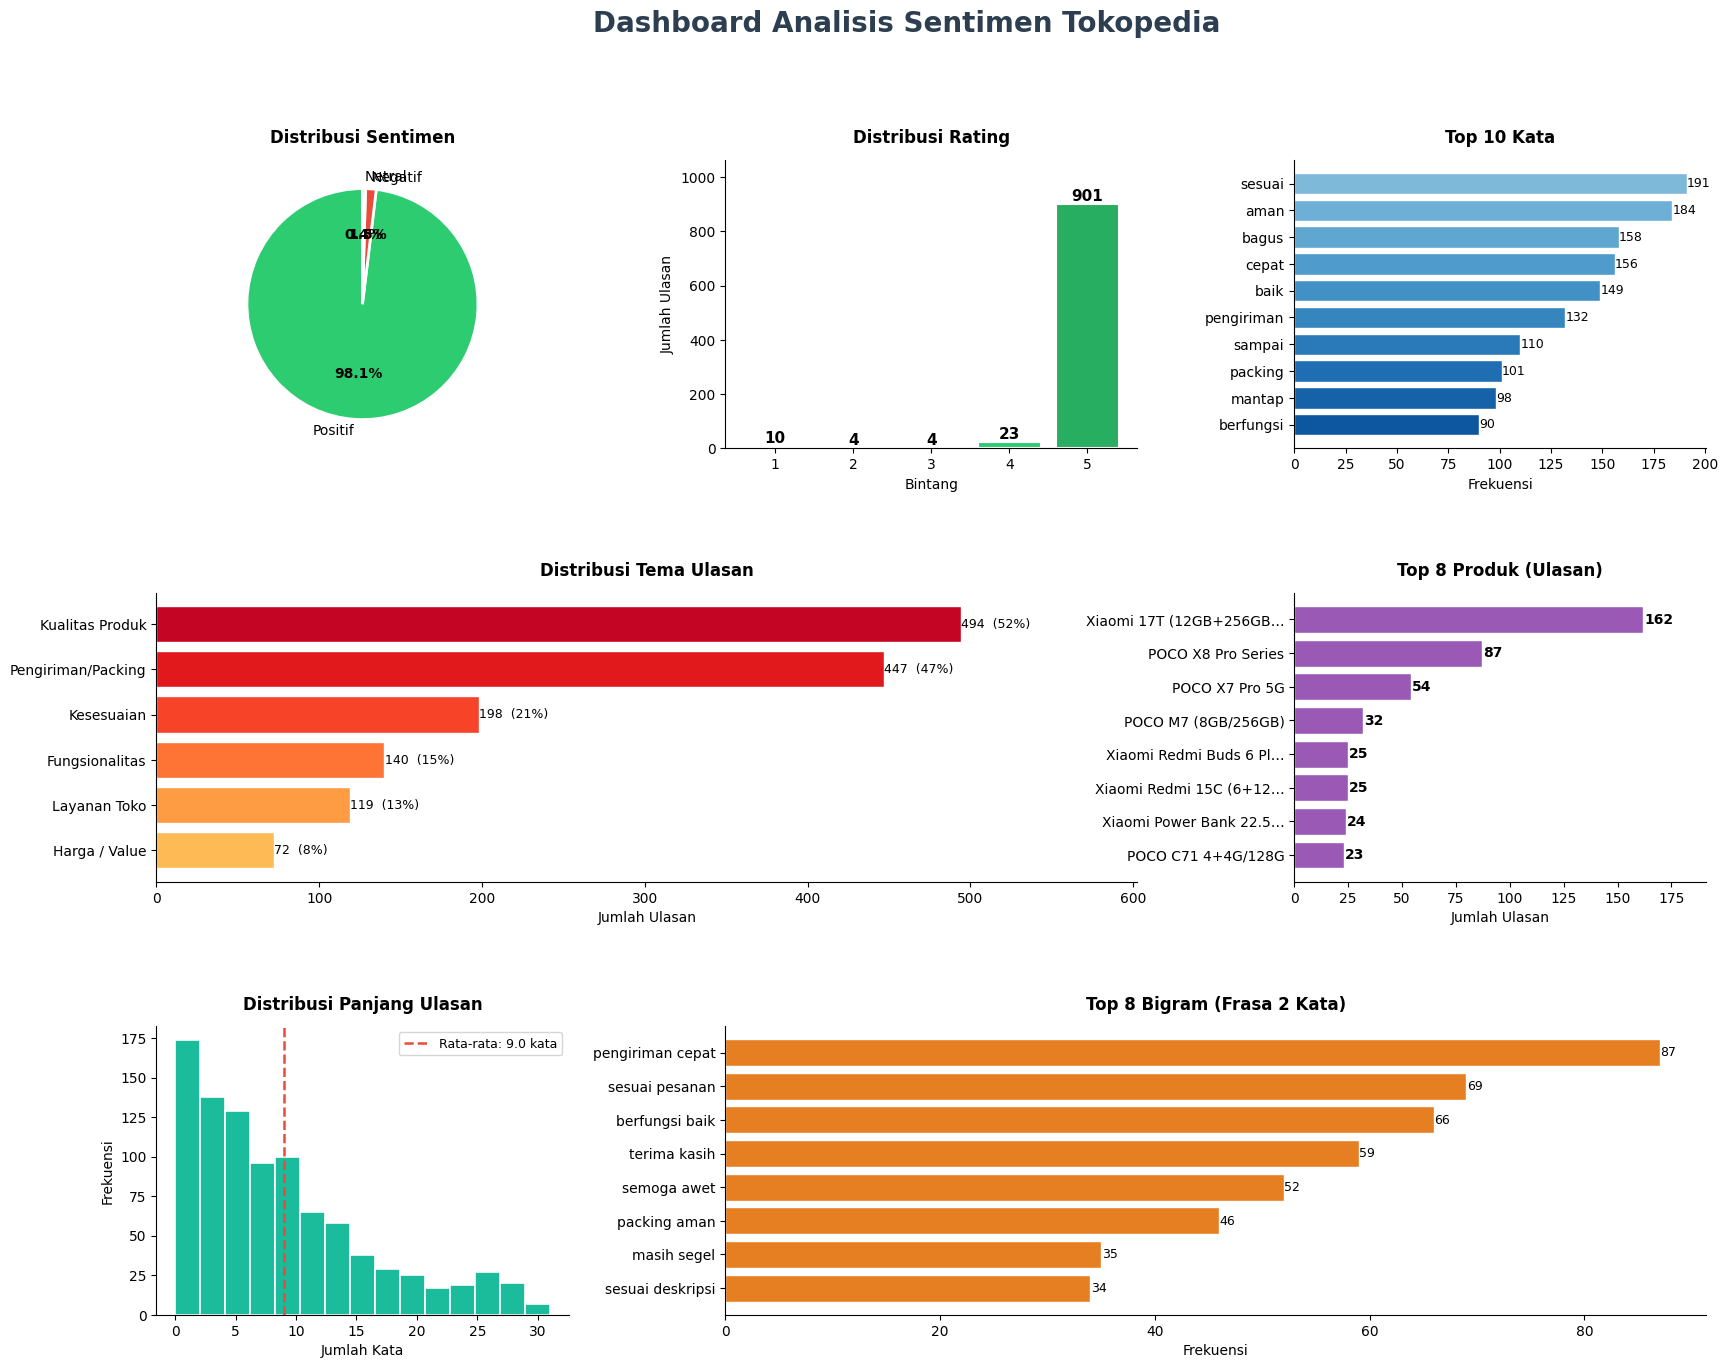

  Dashboard tersimpan ke: C:\Users\radit\Downloads\Tokopedia_Sentiment_dashboard.png


In [18]:
print("\n[4/4] Membuat visualisasi...")
plot_dashboard(df, sentiment_summary, produk_summary,
               df_topics, df_words, df_bigrams, SAVE_PATH)